# This program is used to do Exploratory Data Analysis on the state of OH on precinct perspective

In [26]:
# Import all the libraries
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import re
import numpy as np
from pprint import pprint
from sklearn.linear_model import LinearRegression
import numpy as np

In [27]:


file_path = (r"C:\Huy Phan\College\VoterTurnout\final_data\WA.csv")

OH_data = pd.read_csv(file_path)

In [28]:
OH_data['primary_total_votes'] = OH_data['dem_primary_total'] + OH_data['rep_primary_total']
OH_data['general_total_votes'] = OH_data['dem_general_total'] + OH_data['rep_general_total']

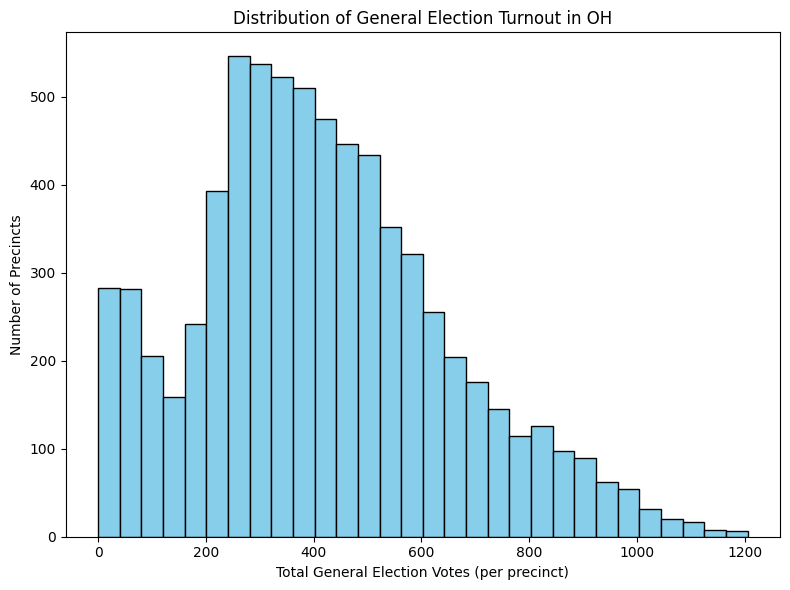

In [29]:
#Distribution of total general votes (Dem + Rep) per precinct

plt.figure(figsize=(8, 6))
plt.hist(OH_data['general_total_votes'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Total General Election Votes (per precinct)')
plt.ylabel('Number of Precincts')
plt.title('Distribution of General Election Turnout in OH')
plt.tight_layout()

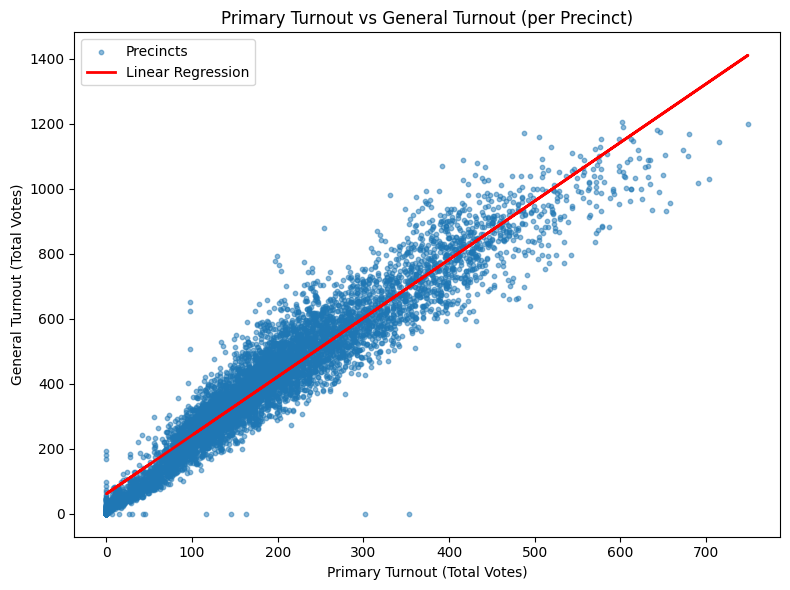

In [30]:
# Prepare X and y for regression
X = OH_data['primary_total_votes'].values.reshape(-1, 1)
y = OH_data['general_total_votes'].values

# Fit linear regression
reg = LinearRegression()
reg.fit(X, y)

# Predict values for the regression line
y_pred = reg.predict(X)

# Plot: Primary turnout vs General turnout with regression line
plt.figure(figsize=(8, 6))
plt.scatter(OH_data['primary_total_votes'], OH_data['general_total_votes'], alpha=0.5, s=10, label='Precincts')
plt.plot(OH_data['primary_total_votes'], y_pred, color='red', linewidth=2, label='Linear Regression')
plt.xlabel('Primary Turnout (Total Votes)')
plt.ylabel('General Turnout (Total Votes)')
plt.title('Primary Turnout vs General Turnout (per Precinct)')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# After fitting the model
beta_0 = reg.intercept_
beta_1 = reg.coef_[0]

print(f"Intercept (β₀): {beta_0:.4f}")
print(f"Slope (β₁): {beta_1:.4f}")

Intercept (β₀): 61.6985
Slope (β₁): 1.8020


In [32]:
# Estimating the size of a precinct uniform precinct size
# OH_data['precinct_size'] = ((OH_data['dem_general_total'] + OH_data['rep_general_total']))/0.75

# Estimate precinct size based geometric approach
# Calculate probability of voting for each party in the general election
OH_data["general_turnout"] = OH_data["rep_general_total"] + OH_data["dem_general_total"]
OH_data["primary_turnout"] = OH_data["rep_primary_total"] + OH_data["dem_primary_total"]
general_turnoutprob = 0.71 # General turnout prob for Rep
primary_turnoutprob= 0.42 # Primary turnout prob for Rep
m = general_turnoutprob / primary_turnoutprob
OH_data["general_turnout_est"] = (OH_data['primary_turnout'] + m * OH_data['general_turnout']) / (1 + m **2)
OH_data["precinct_size"] = OH_data["general_turnout_est"] / primary_turnoutprob 

In [33]:
# Calculate the margin of each precinct margin = abs(rep_primary_total - dem_primary_total) / (rep_primary_total + dem_primary_total)
OH_data['primary_margin'] = np.abs(OH_data['rep_primary_total'] - OH_data['dem_primary_total']) / (OH_data['rep_primary_total'] + OH_data['dem_primary_total'])


In [34]:
# Calculate estimated number of Democratic voters per precinct
OH_data['dem_voters'] = (OH_data['dem_primary_total'] / (OH_data['dem_primary_total'] + OH_data['rep_primary_total'])) * OH_data['precinct_size']
OH_data['rep_voters'] = (OH_data['rep_primary_total'] / (OH_data['dem_primary_total'] + OH_data['rep_primary_total'])) * OH_data['precinct_size']

# 1) Compute primary turnout rate
# OH_data['primary_turnout'] = (
#     OH_data['dem_primary_total'] + OH_data['rep_primary_total']
# )
# OH_data['primary_turnout_rate'] = (
#     OH_data['primary_turnout'] / OH_data['precinct_size']
# )

# # 2) Compute raw Democratic share among primary voters
# OH_data['dem_primary_share'] = (
#     OH_data['dem_primary_total'] / OH_data['primary_turnout']
# )

# # 3) Shrink that share toward 0.5 in proportion to turnout
# OH_data['dem_share_adj'] = (
#     OH_data['primary_turnout_rate'] * OH_data['dem_primary_share']
#   + (1 - OH_data['primary_turnout_rate']) * 0.5
# )
# # Republican share is just the complement
# OH_data['rep_share_adj'] = 1 - OH_data['dem_share_adj']

# # 4) Recompute “voter‐counts” in each precinct
# OH_data['dem_voters'] = OH_data['dem_share_adj'] * OH_data['precinct_size']
# OH_data['rep_voters'] = OH_data['rep_share_adj'] * OH_data['precinct_size']


In [35]:
# Determine the winner based on primary totals
OH_data['primary_winner'] = np.where(
    OH_data['rep_primary_total'] > OH_data['dem_primary_total'], 'rep', 'dem'
)  

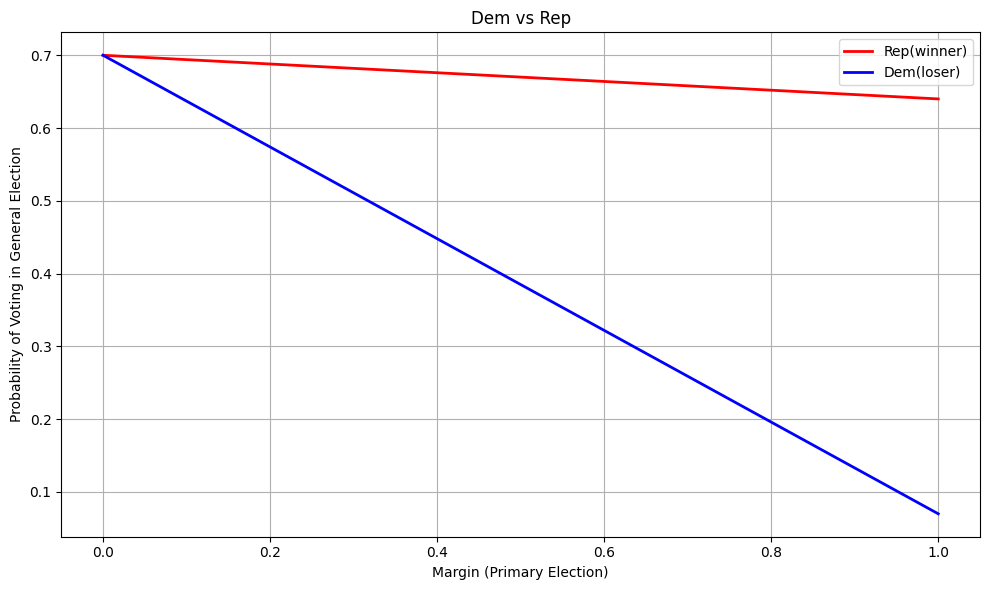

In [36]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b = 0.7          # max vote probability at tie
m_w = 0.06      # steeper slope for winner
m_l = 0.63        # flatter slope for loser

# Calculate probabilities
prob_winner = b - m_w * margins
prob_loser = b - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_winner, label="Rep(winner)", color='red', linewidth=2)
plt.plot(margins, prob_loser, label="Dem(loser)", color='blue', linewidth=2)

# Labels and titles
plt.title("Dem vs Rep")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
# 1. Estimate number of non-primary voters for each party
OH_data['predicted_dem_gen'] = np.where(
    OH_data['primary_winner'] == 'dem',
    (b - OH_data['primary_margin'] * m_w)* OH_data['dem_voters'],  
    (b - OH_data['primary_margin'] * m_l)* OH_data['dem_voters']
)

# For Republicans
OH_data['predicted_rep_gen'] = np.where(
    OH_data['primary_winner'] == 'rep',
    (b - OH_data['primary_margin'] * m_w)* OH_data['rep_voters'],  
    (b - OH_data['primary_margin'] * m_l)* OH_data['rep_voters']
)

In [38]:
# Compare to actual general vote shares
OH_data['actual_general_rep_share'] = OH_data['rep_general_total'] / (
    OH_data['rep_general_total'] + OH_data['dem_general_total']
)
OH_data['predicted_rep_share'] = OH_data['predicted_rep_gen'] / (
    OH_data['predicted_rep_gen'] + OH_data['predicted_dem_gen']
)
OH_data['primary_rep_voteshare'] = OH_data['rep_primary_total'] / (
    OH_data['rep_primary_total'] + OH_data['dem_primary_total']
)



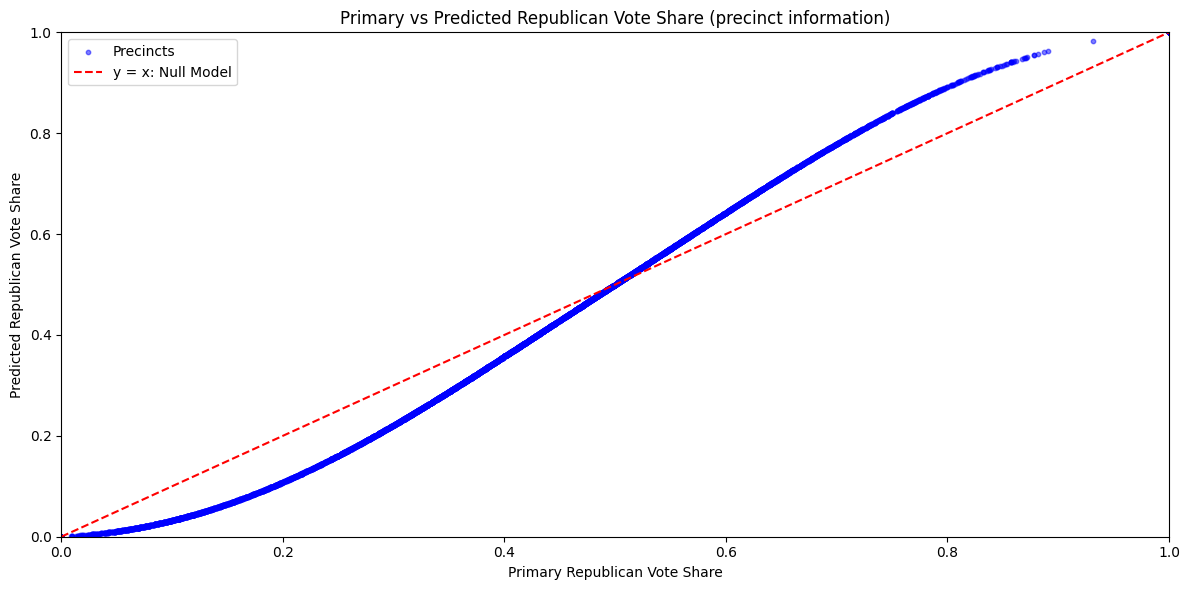

In [39]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['primary_rep_voteshare'], 
    y=OH_data['predicted_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Primary Republican Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


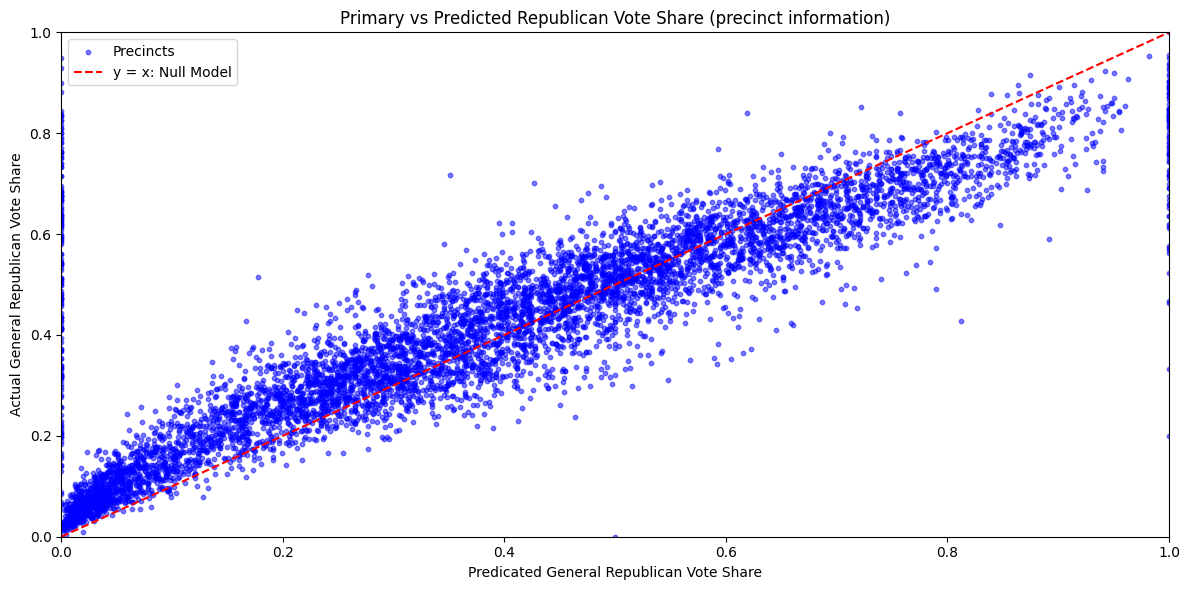

In [40]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['predicted_rep_share'], 
    y=OH_data['actual_general_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## State - level Information

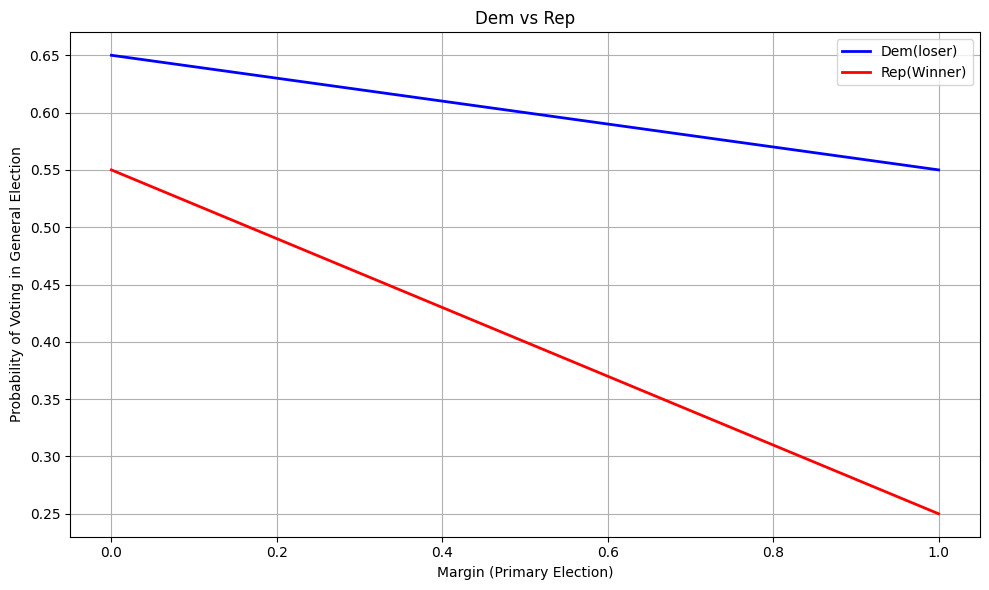

In [41]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b_w = 0.55          # max vote probability at tie
b_l = 0.65
m_w = 0.3      # steeper slope for winner
m_l = 0.1        # flatter slope for loser

# Calculate probabilities
prob_winner = b_w - m_w * margins
prob_loser = b_l - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_loser, label="Dem(loser)", color='blue', linewidth=2)
plt.plot(margins, prob_winner, label="Rep(Winner)", color='red', linewidth=2)

# Labels and titles
plt.title("Dem vs Rep")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
# Determine the winner based on primary totals
# OH_data['state_primary_winner'] = np.where(
#     OH_data['rep_primary_total'].sum() > OH_data['dem_primary_total'].sum(), 'rep', 'dem'
# )  
OH_data['state_primary_winner'] = np.where(
    OH_data['rep_primary_total'].sum() > OH_data['dem_primary_total'].sum(), 'rep', 'dem'
)  

In [43]:
OH_data

,precinct,pri_dem_CLINTON,pri_dem_SANDERS,pri_rep_CARSON,pri_rep_CRUZ,pri_rep_KASICH,pri_rep_TRUMP,gen_con_CASTLE,gen_dem_CLINTON,gen_grn_STEIN,...,primary_margin,dem_voters,rep_voters,primary_winner,predicted_dem_gen,predicted_rep_gen,actual_general_rep_share,predicted_rep_share,primary_rep_voteshare,state_primary_winner
0,ADAMSBATUM,2,6,5,4,0,34,0,10,2,...,0.686275,22.285805,119.786201,rep,5.964730,78.917968,0.905660,0.929730,0.843137,dem
1,ADAMSBENGE,3,2,0,3,0,14,0,4,0,...,0.545455,10.911095,37.097722,rep,3.888317,24.754298,0.878788,0.864247,0.772727,dem
2,ADAMSCUNNINGHAM,0,0,0,0,0,0,0,6,0,...,NaN,NaN,NaN,dem,NaN,NaN,0.571429,NaN,NaN,dem
3,ADAMSFAIRVIEW,2,2,0,0,0,0,0,5,0,...,1.000000,35.855988,0.000000,dem,22.947832,0.000000,0.843750,0.000000,0.000000,dem
4,ADAMSHATTON CITY,0,0,0,0,0,0,0,2,0,...,NaN,NaN,NaN,dem,NaN,NaN,0.925926,NaN,NaN,dem
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7109,YAKIMA5020.5839999999998,26,11,6,15,12,100,1,95,4,...,0.564706,98.908674,355.536586,rep,34.047857,236.829194,0.716418,0.874305,0.782353,dem
7110,YAKIMA5101.38,19,26,0,6,5,72,0,91,2,...,0.296875,125.710071,231.865242,rep,64.485338,158.175569,0.659176,0.710388,0.648438,dem
7111,YAKIMA5202.473,0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,dem,NaN,NaN,NaN,NaN,NaN,dem
7112,YAKIMA701.6,26,25,10,3,2,22,0,97,1,...,0.159091,122.177209,88.638368,dem,84.357809,53.162875,0.353333,0.386581,0.420455,dem


In [44]:
# 1. Estimate number of non-primary voters for each party
OH_data['predicted_dem_gen_state'] = np.where(
    OH_data['state_primary_winner'] == 'dem',
    (b_w - OH_data['primary_margin'] * m_w)* OH_data['dem_voters'],  
    (b_l - OH_data['primary_margin'] * m_l)* OH_data['dem_voters']
)

# For Republicans
OH_data['predicted_rep_gen_state'] = np.where(
    OH_data['state_primary_winner'] == 'rep',
    (b_w - OH_data['primary_margin'] * m_w)* OH_data['rep_voters'],  
    (b_l - OH_data['primary_margin'] * m_l)* OH_data['rep_voters']
)


In [45]:
# Compute predicted Republican vote share based on state primary winner
OH_data['predicted_rep_share_state'] = OH_data['predicted_rep_gen_state'] / (
    OH_data['predicted_rep_gen_state'] + OH_data['predicted_dem_gen_state']
)

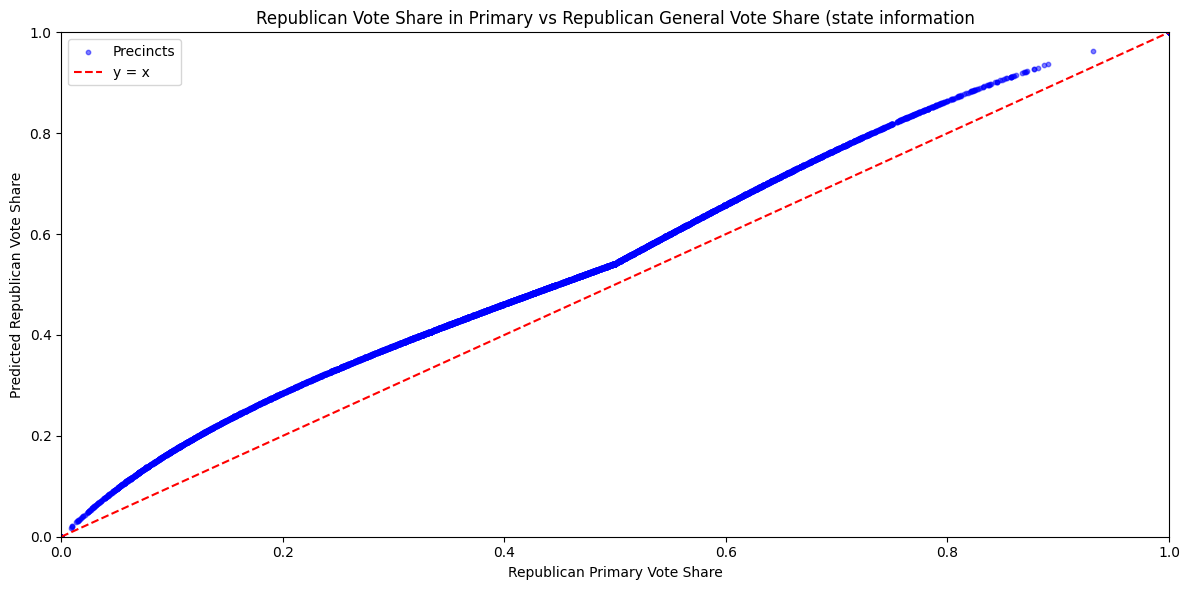

In [46]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['primary_rep_voteshare'], 
    y=OH_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x')
plt.title('Republican Vote Share in Primary vs Republican General Vote Share (state information')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


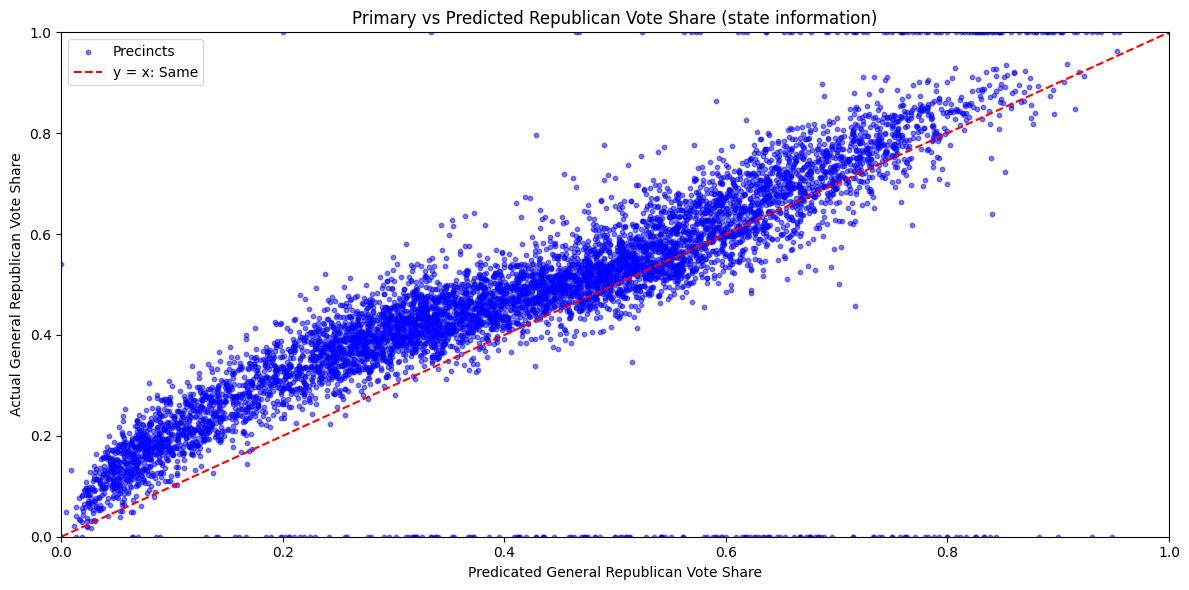

In [47]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['actual_general_rep_share'], 
    y=OH_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Same')
plt.title('Primary vs Predicted Republican Vote Share (state information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Plotting these 2 effects

In [48]:
OH_data

,precinct,pri_dem_CLINTON,pri_dem_SANDERS,pri_rep_CARSON,pri_rep_CRUZ,pri_rep_KASICH,pri_rep_TRUMP,gen_con_CASTLE,gen_dem_CLINTON,gen_grn_STEIN,...,primary_winner,predicted_dem_gen,predicted_rep_gen,actual_general_rep_share,predicted_rep_share,primary_rep_voteshare,state_primary_winner,predicted_dem_gen_state,predicted_rep_gen_state,predicted_rep_share_state
0,ADAMSBATUM,2,6,5,4,0,34,0,10,2,...,rep,5.964730,78.917968,0.905660,0.929730,0.843137,dem,7.668939,69.640409,0.900802
1,ADAMSBENGE,3,2,0,3,0,14,0,4,0,...,rep,3.888317,24.754298,0.878788,0.864247,0.772727,dem,4.215650,22.090007,0.839744
2,ADAMSCUNNINGHAM,0,0,0,0,0,0,0,6,0,...,dem,NaN,NaN,0.571429,NaN,NaN,dem,NaN,NaN,NaN
3,ADAMSFAIRVIEW,2,2,0,0,0,0,0,5,0,...,dem,22.947832,0.000000,0.843750,0.000000,0.000000,dem,8.963997,0.000000,0.000000
4,ADAMSHATTON CITY,0,0,0,0,0,0,0,2,0,...,dem,NaN,NaN,0.925926,NaN,NaN,dem,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7109,YAKIMA5020.5839999999998,26,11,6,15,12,100,1,95,4,...,rep,34.047857,236.829194,0.716418,0.874305,0.782353,dem,37.643478,211.021421,0.848618
7110,YAKIMA5101.38,19,26,0,6,5,72,0,91,2,...,rep,64.485338,158.175569,0.659176,0.710388,0.648438,dem,57.944486,143.828908,0.712824
7111,YAKIMA5202.473,0,0,0,0,0,0,0,0,0,...,dem,NaN,NaN,NaN,NaN,NaN,dem,NaN,NaN,NaN
7112,YAKIMA701.6,26,25,10,3,2,22,0,97,1,...,dem,84.357809,53.162875,0.353333,0.386581,0.420455,dem,61.366280,56.204783,0.478049


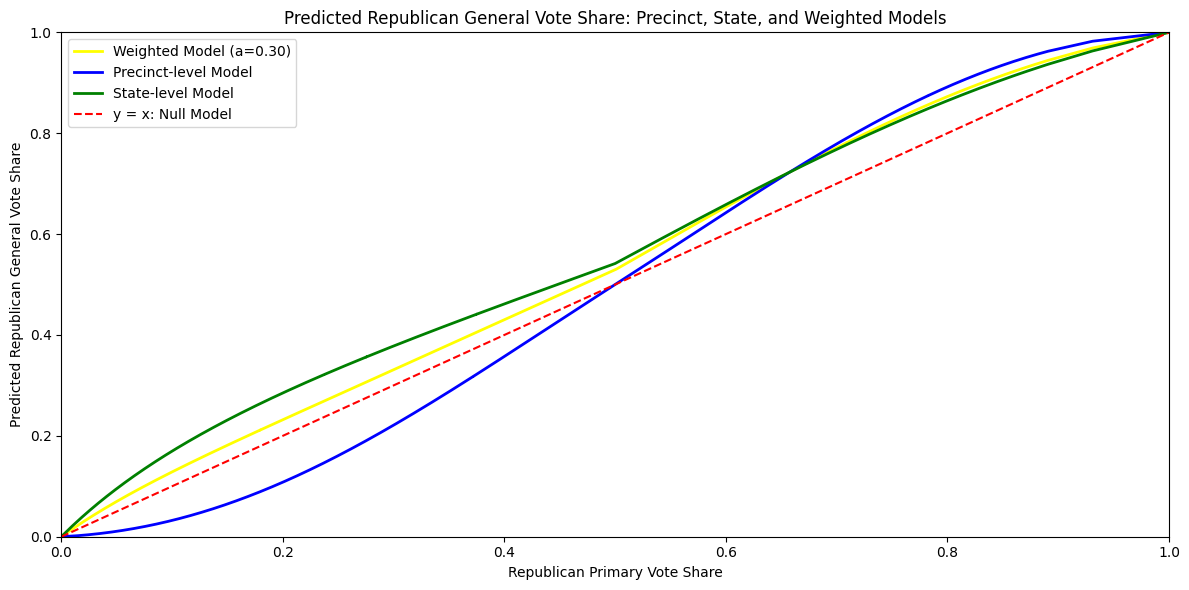

In [49]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.3  

OH_data['predicted_rep_share_weighted'] = (
    a * OH_data['predicted_rep_share'] +
    (1 - a) * OH_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = OH_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='green', linewidth=2, label='State-level Model'
)

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

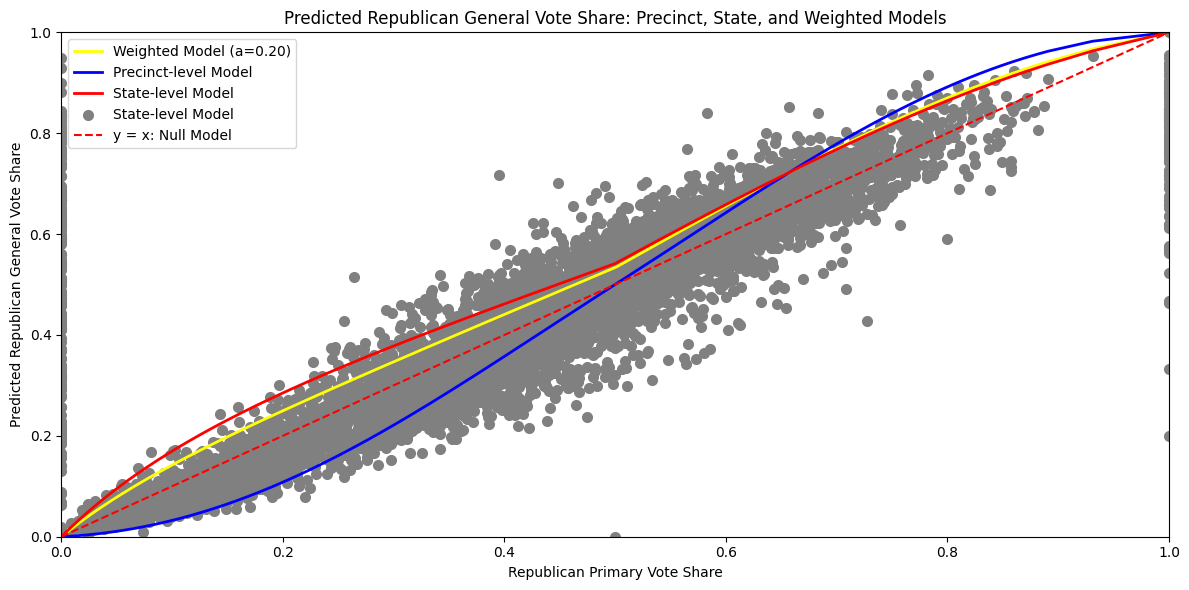

In [50]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.2  

OH_data['predicted_rep_share_weighted'] = (
    a * OH_data['predicted_rep_share'] +
    (1 - a) * OH_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = OH_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='red', linewidth=2, label='State-level Model'
)
plt.scatter(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['actual_general_rep_share'],
    color='gray', linewidth=2, label='State-level Model'
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()